In [2]:
import sys, os
sys.path.append(os.path.abspath('..'))

In [3]:
from src.preprocess import load_and_preprocess
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score


In [4]:
X_train, X_test, y_train, y_test = load_and_preprocess('../data/diabetes.csv')

In [5]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [6]:
y_pred = nb_model.predict(X_test)

In [7]:
accuracy = accuracy_score(y_test, y_pred)
print("Naive Bayes Accuracy:", accuracy)

Naive Bayes Accuracy: 0.7662337662337663


In [8]:
nb_probs = nb_model.predict_proba(X_test)
print(nb_probs[:5])

[[0.73024905 0.26975095]
 [0.93694871 0.06305129]
 [0.96883706 0.03116294]
 [0.8148359  0.1851641 ]
 [0.45360546 0.54639454]]


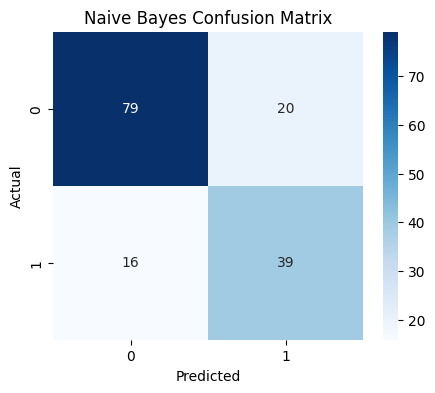

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [10]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.80      0.81        99
           1       0.66      0.71      0.68        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



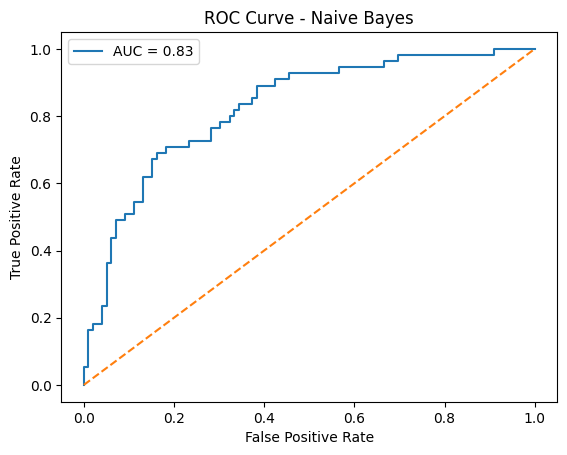

In [11]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, nb_probs[:,1])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Naive Bayes")
plt.legend()
plt.show()

In [12]:
print("Sample probabilities:")
print(nb_probs[:5])

Sample probabilities:
[[0.73024905 0.26975095]
 [0.93694871 0.06305129]
 [0.96883706 0.03116294]
 [0.8148359  0.1851641 ]
 [0.45360546 0.54639454]]
